### import

In [1]:
import os
# import sys
import numpy as np

from matplotlib import pyplot as plt
from  astropy.io import fits

from simple_veloce_reduction import veloce_reduction_tools
from simple_veloce_reduction import veloce_config

In [2]:
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titlesize': 10,
    'axes.labelsize': 8,
    'axes.linewidth': 0.5,
    'lines.linewidth': 1.0,
    'lines.markersize': 5,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.major.size': 3,
    'xtick.minor.size': 1.5,
    'ytick.major.size': 3,
    'ytick.minor.size': 1.5,
    'xtick.major.width': 0.5,
    'xtick.minor.width': 0.5,
    'ytick.major.width': 0.5,
    'ytick.minor.width': 0.5,
    'legend.fontsize': 6,
    'legend.frameon': False,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.6,
    'pdf.fonttype': 42,
})

In [2]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


### Functions

In [3]:
def get_overscan_regions(frame, overscan_range=32):
    ylen, xlen = frame.shape
    ydiv = ylen // 2
    xdiv = xlen // 2
    
    overscan_regions = {
        # top left - Q1
        # middle
        'q1_mid_parallel': frame[ydiv:,xdiv-overscan_range:xdiv],
        'q1_mid_serial': frame[ydiv:ydiv+overscan_range,:xdiv],
        # edge
        'q1_edge_parallel': frame[ydiv:,:overscan_range],
        'q1_edge_serial': frame[ylen-overscan_range:,:xdiv],
        'q1_coordinates': [(ydiv, ylen), (0, xdiv)],

        # bottom left - Q2
        # middle
        'q2_mid_parallel': frame[:ydiv,xdiv-overscan_range:xdiv],
        'q2_mid_serial': frame[ydiv-overscan_range:ydiv,:xdiv],
        # edge
        'q2_edge_parallel': frame[:ydiv,:overscan_range],
        'q2_edge_serial': frame[:overscan_range,:xdiv],
        'q2_coordinates': [(0, ydiv), (0, xdiv)],


        # bottom right - Q3
        # middle
        'q3_mid_parallel': frame[:ydiv,xdiv:xdiv+overscan_range],
        'q3_mid_serial': frame[ydiv-overscan_range:ydiv,xdiv:],
        # edge
        'q3_edge_parallel': frame[:ydiv,xlen-overscan_range:],
        'q3_edge_serial': frame[:overscan_range,xdiv:],
        'q3_coordinates': [(0, ydiv), (xdiv, xlen)],

        # top right - Q4
        # middle
        'q4_mid_parallel': frame[ydiv:,xdiv:xdiv+overscan_range],
        'q4_mid_serial': frame[ydiv:ydiv+overscan_range,xdiv:],
        # edge
        'q4_edge_parallel': frame[ydiv:,xlen-overscan_range:],
        'q4_edge_serial': frame[ylen-overscan_range:,xdiv:],
        'q4_coordinates': [(ydiv, ylen), (xdiv, xlen)],
    }

    return overscan_regions

### Load data

In [13]:
run = "CSV_Run"
date = '230824'
ccd_nums = {'red': 3, 'green': 2, 'blue': 1}
# arm = 'blue'
arm = 'green'
# arm = 'red'
ccd = f'ccd_{ccd_nums[arm]}'
amplifier_mode = 4
science_targets = 'Default'

In [14]:
input_dir = f'~/VeloceData/{run}/'
output_dir = '/Users/jjkruger/veloce_demonstration/Bias/'

In [15]:
veloce_paths = veloce_config.VelocePaths(input_dir=input_dir, output_dir=output_dir)

In [16]:
config = veloce_config.make_config(input_dir, output_dir, date=date, arm=arm, amplifier_mode=amplifier_mode, science_targets=science_targets)

In [17]:
obs_list = veloce_config.load_night_logs(science_targets, veloce_paths, config)

In [19]:
file_list = obs_list[f'bias'][date]

In [21]:
with fits.open(os.path.join(veloce_paths.input_dir, date, ccd, file_list[-2])) as hdul:
    frame = hdul[0].data
overscan_regions = get_overscan_regions(frame)
ylen, xlen = frame.shape
ydiv = ylen // 2
xdiv = xlen // 2
overscan_range = 32

In [22]:
%matplotlib inline
# %matplotlib widget

In [23]:
overscan_regions['q1_coordinates'], overscan_regions['q2_coordinates'], overscan_regions['q3_coordinates'], overscan_regions['q4_coordinates']

([(2120, 4240), (0, 2112)],
 [(0, 2120), (0, 2112)],
 [(0, 2120), (2112, 4224)],
 [(2120, 4240), (2112, 4224)])

### Q1

In [25]:
overscan_regions['q1_mid_parallel'].shape

(2120, 32)

In [26]:
q1_overscans = np.concatenate(
    [overscan_regions['q1_mid_serial'][:,:].flatten(),
    overscan_regions['q1_mid_parallel'][overscan_range:-overscan_range,:].flatten(),
    overscan_regions['q1_edge_serial'][:,:].flatten(),
    overscan_regions['q1_edge_parallel'][overscan_range:-overscan_range,:].flatten()]
)
q1_median = np.median(q1_overscans)
q1_median

np.float64(992.0)

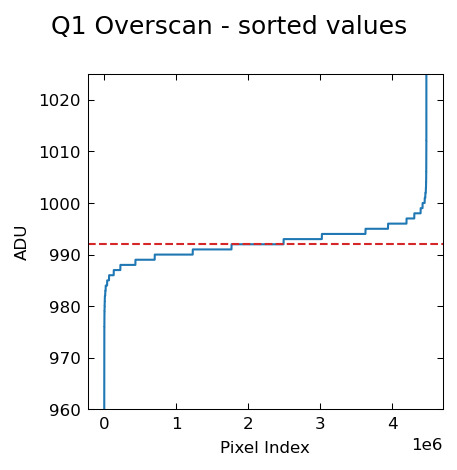

In [27]:
plt.close('all')
fig, axes = plt.subplots(1, 1, figsize=(3.15, 3.15), sharey=True)
fig.suptitle('Q1 Overscan - sorted values')

axes.plot(np.sort(frame[ydiv:, :xdiv].flatten()))
axes.axhline(q1_median, color='C3', ls='--')
# axes.set_yscale('log')
axes.set_xlabel('Pixel Index')
axes.set_ylabel('ADU')
axes.set_ylim(np.percentile(frame[ydiv:, :xdiv], 1)-25, np.percentile(frame[ydiv:, :xdiv], 99)+25)
plt.tight_layout()

(32,) (32, 2112)


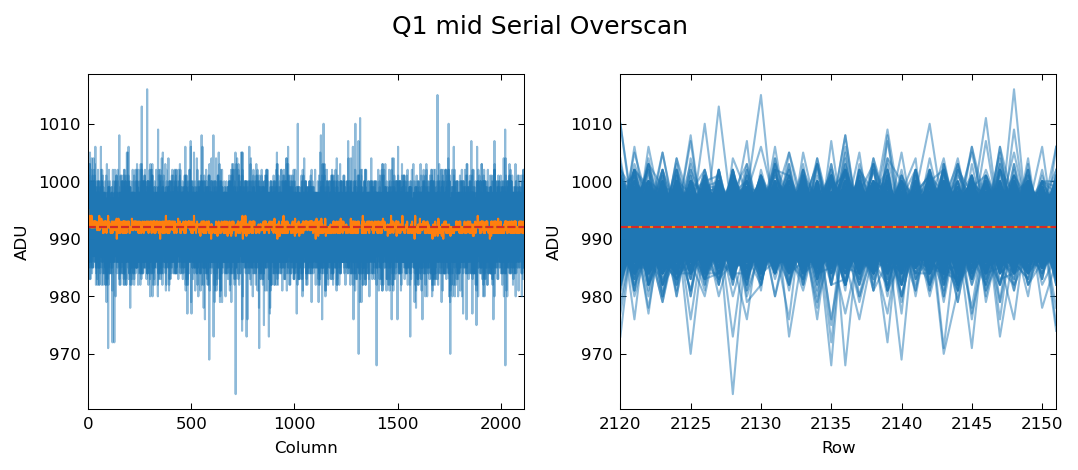

In [28]:
# Q1 mid serial overscan
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Q1 mid Serial Overscan')
xarr =  np.arange(overscan_regions['q1_coordinates'][1][0], overscan_regions['q1_coordinates'][1][1], 1)
for i in range(overscan_regions['q1_mid_serial'].shape[0]):
    axes[0].plot(xarr,overscan_regions['q1_mid_serial'][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(overscan_regions['q1_mid_serial'], axis=0), color='C1')
axes[0].axhline(np.median(overscan_regions['q1_mid_serial']), color='C2', ls='--')
axes[0].axhline(q1_median, color='C3', ls='--')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_xlim(overscan_regions['q1_coordinates'][1][0], overscan_regions['q1_coordinates'][1][1])
# xticks = axes[0].get_xticks()
# print(xticks)
# labels = xarr[xticks.astype(int)]
# # axes[0].set_xticks(xticks)
# axes[0].set_xticklabels(labels)

xarr =  np.arange(overscan_regions['q1_coordinates'][0][0], overscan_regions['q1_coordinates'][0][0]+overscan_range, 1)
print(xarr.shape, overscan_regions['q1_mid_serial'].shape)
for i in range(overscan_regions['q1_mid_serial'].shape[1]):
    axes[1].plot(xarr, overscan_regions['q1_mid_serial'][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(overscan_regions['q1_mid_serial'], axis=1), color='C1')
axes[1].axhline(np.median(overscan_regions['q1_mid_serial']), color='C2', ls='--')
axes[1].axhline(q1_median, color='C3', ls='--')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_xlim(overscan_regions['q1_coordinates'][0][0], overscan_regions['q1_coordinates'][0][0]+overscan_range-1)
# xticks = axes[1].get_xticks()
# labels = xarr[xticks.astype(int)]
# # axes[1].set_xticks(xticks)
# axes[1].set_xticklabels(labels)
plt.tight_layout()

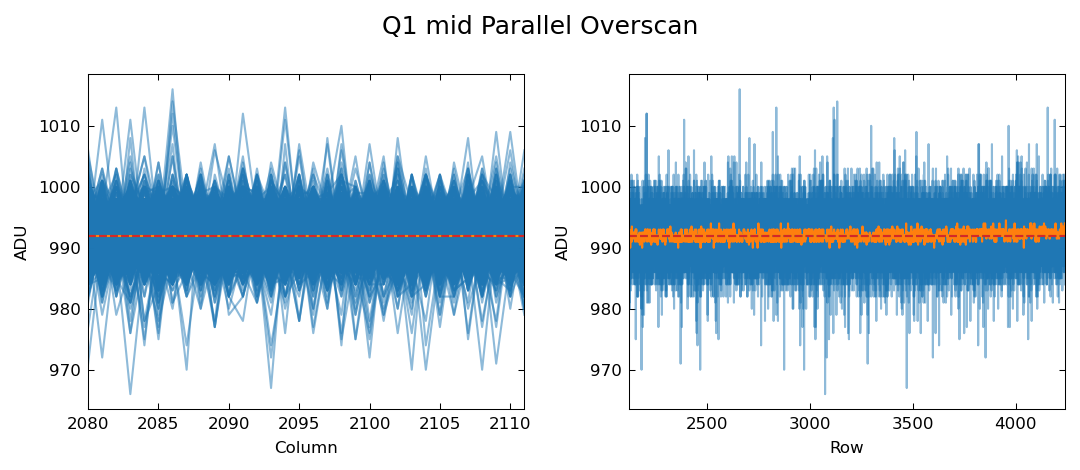

In [29]:
# Q1 mid parallel overscan
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Q1 mid Parallel Overscan')
xarr = np.arange(overscan_regions['q1_coordinates'][1][1]-overscan_range, overscan_regions['q1_coordinates'][1][1], 1)
for i in range(overscan_regions['q1_mid_parallel'].shape[0]):
    axes[0].plot(xarr, overscan_regions['q1_mid_parallel'][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(overscan_regions['q1_mid_parallel'], axis=0), color='C1')
axes[0].axhline(np.median(overscan_regions['q1_mid_parallel']), color='C2', ls='--')
axes[0].axhline(q1_median, color='C3', ls='--')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_xlim(overscan_regions['q1_coordinates'][1][1]-overscan_range, overscan_regions['q1_coordinates'][1][1]-1)

xarr = np.arange(overscan_regions['q1_coordinates'][0][0], overscan_regions['q1_coordinates'][0][1], 1)
for i in range(overscan_regions['q1_mid_parallel'].shape[1]):
    axes[1].plot(xarr, overscan_regions['q1_mid_parallel'][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(overscan_regions['q1_mid_parallel'], axis=1), color='C1')
axes[1].axhline(np.median(overscan_regions['q1_mid_parallel']), color='C2', ls='--')
axes[1].axhline(q1_median, color='C3', ls='--')
# axes[1].set_title('Q1 mid Parallel Overscan - Columns')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_xlim(overscan_regions['q1_coordinates'][0][0], overscan_regions['q1_coordinates'][0][1])
plt.tight_layout()

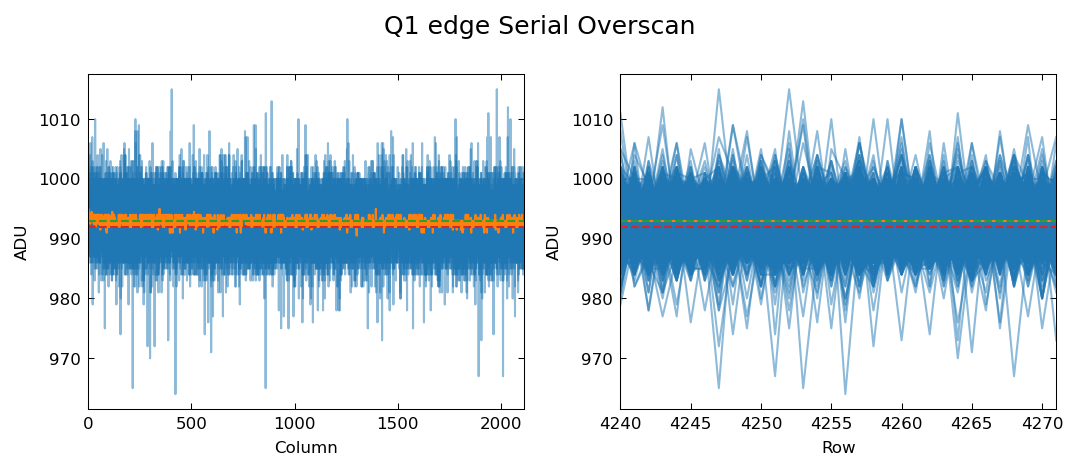

In [30]:
# Q1 edge serial overscan
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Q1 edge Serial Overscan')
xarr = np.arange(overscan_regions['q1_coordinates'][1][0], overscan_regions['q1_coordinates'][1][1], 1)
for i in range(overscan_regions['q1_edge_serial'].shape[0]):
    axes[0].plot(xarr, overscan_regions['q1_edge_serial'][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(overscan_regions['q1_edge_serial'], axis=0), color='C1')
axes[0].axhline(np.median(overscan_regions['q1_edge_serial']), color='C2', ls='--')
axes[0].axhline(q1_median, color='C3', ls='--')
# axes[0].set_title('Q1 edge Serial Overscan - Rows')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_xlim(overscan_regions['q1_coordinates'][1][0], overscan_regions['q1_coordinates'][1][1]-1)

xarr = np.arange(overscan_regions['q1_coordinates'][0][1], overscan_regions['q1_coordinates'][0][1]+overscan_range, 1)
for i in range(overscan_regions['q1_edge_serial'].shape[1]):
    axes[1].plot(xarr, overscan_regions['q1_edge_serial'][:,i], alpha=0.5, c='C0')
# axes[1].plot(np.mean(overscan_regions['q1_edge_serial'], axis=1))
axes[1].plot(xarr, np.median(overscan_regions['q1_edge_serial'], axis=1), color='C1')
axes[1].axhline(np.median(overscan_regions['q1_edge_serial']), color='C2', ls='--')
axes[1].axhline(q1_median, color='C3', ls='--')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_xlim(overscan_regions['q1_coordinates'][0][1], overscan_regions['q1_coordinates'][0][1]+overscan_range-1)
plt.tight_layout()

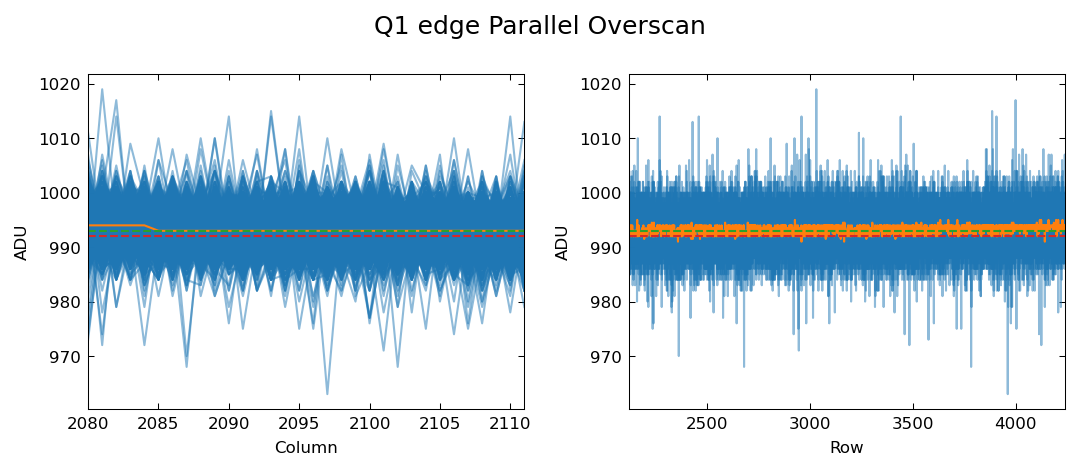

In [31]:
# Q1 edge parallel overscan
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Q1 edge Parallel Overscan')
xarr = np.arange(overscan_regions['q1_coordinates'][1][1]-overscan_range, overscan_regions['q1_coordinates'][1][1], 1)
for i in range(overscan_regions['q1_edge_parallel'].shape[0]):
    axes[0].plot(xarr, overscan_regions['q1_edge_parallel'][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(overscan_regions['q1_edge_parallel'], axis=0), color='C1')
axes[0].axhline(np.median(overscan_regions['q1_edge_parallel']), color='C2', ls='--')
axes[0].axhline(q1_median, color='C3', ls='--')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_xlim(overscan_regions['q1_coordinates'][1][1]-overscan_range, overscan_regions['q1_coordinates'][1][1]-1)

xarr = np.arange(overscan_regions['q1_coordinates'][0][0], overscan_regions['q1_coordinates'][0][1], 1)
for i in range(overscan_regions['q1_edge_parallel'].shape[1]):
    axes[1].plot(xarr, overscan_regions['q1_edge_parallel'][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(overscan_regions['q1_edge_parallel'], axis=1), color='C1')
axes[1].axhline(np.median(overscan_regions['q1_edge_parallel']), color='C2', ls='--')
axes[1].axhline(q1_median, color='C3', ls='--')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_xlim(overscan_regions['q1_coordinates'][0][0], overscan_regions['q1_coordinates'][0][1]-1)
plt.tight_layout()

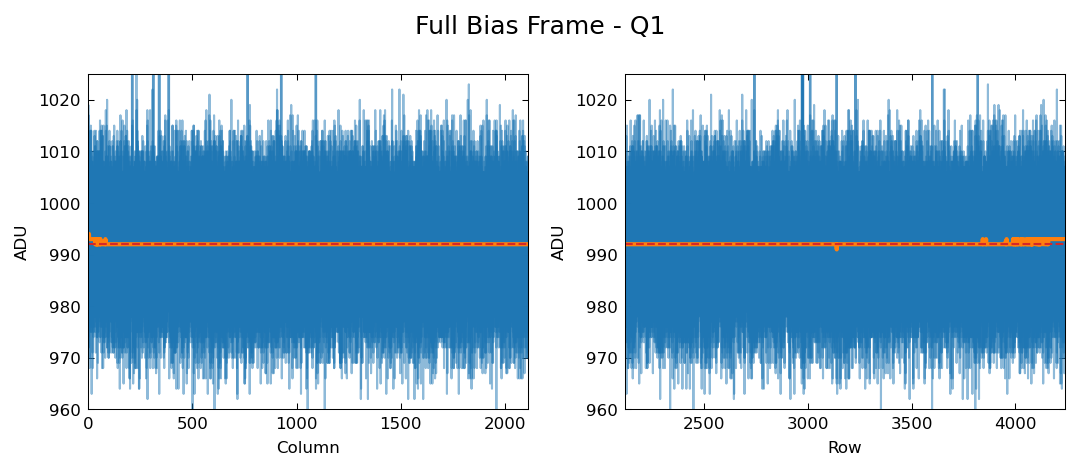

In [32]:
# full Q1 bias frame
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Full Bias Frame - Q1')
xarr = np.arange(overscan_regions['q1_coordinates'][1][0], overscan_regions['q1_coordinates'][1][1], 1)
for i in range(frame[ydiv:, :xdiv].shape[0]):
    axes[0].plot(xarr, frame[ydiv:, :xdiv][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(frame[ydiv:, :xdiv], axis=0), c='C1', linewidth=2)
axes[0].axhline(q1_median, color='C3', ls='--')
# axes[0].set_title('Q1 Bias Frame - Rows')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_ylim(np.percentile(frame[ydiv:, :xdiv], 1)-25, np.percentile(frame[ydiv:, :xdiv], 99)+25)
axes[0].set_xlim(overscan_regions['q1_coordinates'][1][0], overscan_regions['q1_coordinates'][1][1]-1)

xarr = np.arange(overscan_regions['q1_coordinates'][0][0], overscan_regions['q1_coordinates'][0][1], 1)
for i in range(frame[ydiv:, :xdiv].shape[1]):
    axes[1].plot(xarr, frame[ydiv:, :xdiv][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(frame[ydiv:, :xdiv], axis=1), c='C1', linewidth=2)
axes[1].axhline(q1_median, color='C3', ls='--')
# axes[1].set_title('Q1 Bias Frame - Columns')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_ylim(np.percentile(frame[ydiv:, :xdiv], 1)-25, np.percentile(frame[ydiv:, :xdiv], 99)+25)
axes[1].set_xlim(overscan_regions['q1_coordinates'][0][0], overscan_regions['q1_coordinates'][0][1]-1)
plt.tight_layout()

In [33]:
q1_median, np.median(frame[ydiv+overscan_range:ylen-overscan_range,overscan_range:xdiv-overscan_range])

(np.float64(992.0), np.float64(992.0))

### Q2

In [35]:
q2_overscans = np.concatenate(
    [overscan_regions['q2_mid_serial'][:,:].flatten(),
    overscan_regions['q2_mid_parallel'][overscan_range:-overscan_range,:].flatten(),
    overscan_regions['q2_edge_serial'][:,:].flatten(),
    overscan_regions['q2_edge_parallel'][overscan_range:-overscan_range,:].flatten()]
)
q2_median = np.median(q2_overscans)
q2_stdev = np.std(q2_overscans)
q2_median, q2_stdev

(np.float64(1002.0), np.float64(5.486915337395629))

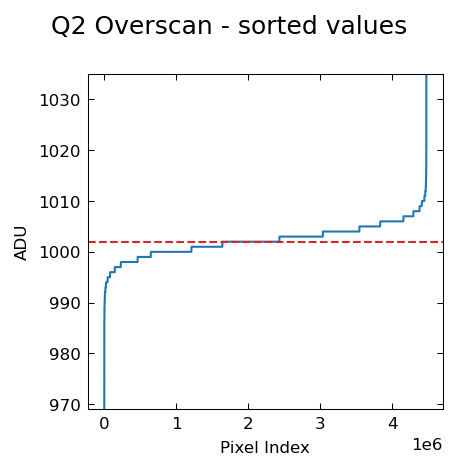

In [36]:
plt.close('all')
fig, axes = plt.subplots(1, 1, figsize=(3.15, 3.15), sharey=True)
fig.suptitle('Q2 Overscan - sorted values')

axes.plot(np.sort(frame[:ydiv, :xdiv].flatten()))
axes.axhline(q2_median, color='C3', ls='--')
# axes.set_yscale('log')
axes.set_xlabel('Pixel Index')
axes.set_ylabel('ADU')
axes.set_ylim(np.percentile(frame[:ydiv, :xdiv], 1)-25, np.percentile(frame[:ydiv, :xdiv], 99)+25)
plt.tight_layout()

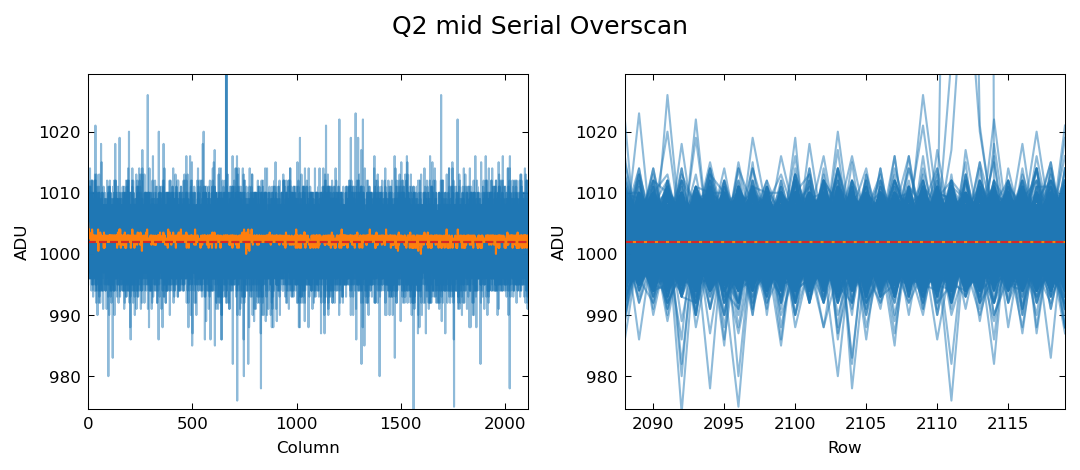

In [38]:
# Q2 mid serial overscan
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Q2 mid Serial Overscan')
xarr = np.arange(overscan_regions['q2_coordinates'][1][0], overscan_regions['q2_coordinates'][1][1], 1)
for i in range(overscan_regions['q2_mid_serial'].shape[0]):
    axes[0].plot(xarr, overscan_regions['q2_mid_serial'][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(overscan_regions['q2_mid_serial'], axis=0), color='C1')
axes[0].axhline(np.median(overscan_regions['q2_mid_serial']), color='C2', ls='--')
axes[0].axhline(q2_median, color='C3', ls='--')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_xlim(overscan_regions['q2_coordinates'][1][0], overscan_regions['q2_coordinates'][1][1]-1)
axes[0].set_ylim(q2_median-5*q2_stdev, q2_median+5*q2_stdev)

xarr = np.arange(overscan_regions['q2_coordinates'][0][1]-overscan_range, overscan_regions['q2_coordinates'][0][1], 1)
for i in range(overscan_regions['q2_mid_serial'].shape[1]):
    axes[1].plot(xarr, overscan_regions['q2_mid_serial'][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(overscan_regions['q2_mid_serial'], axis=1), color='C1')
axes[1].axhline(np.median(overscan_regions['q2_mid_serial']), color='C2', ls='--')
axes[1].axhline(q2_median, color='C3', ls='--')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_xlim(overscan_regions['q2_coordinates'][0][1]-overscan_range, overscan_regions['q2_coordinates'][0][1]-1)
axes[1].set_ylim(q2_median-5*q2_stdev, q2_median+5*q2_stdev)
plt.tight_layout()

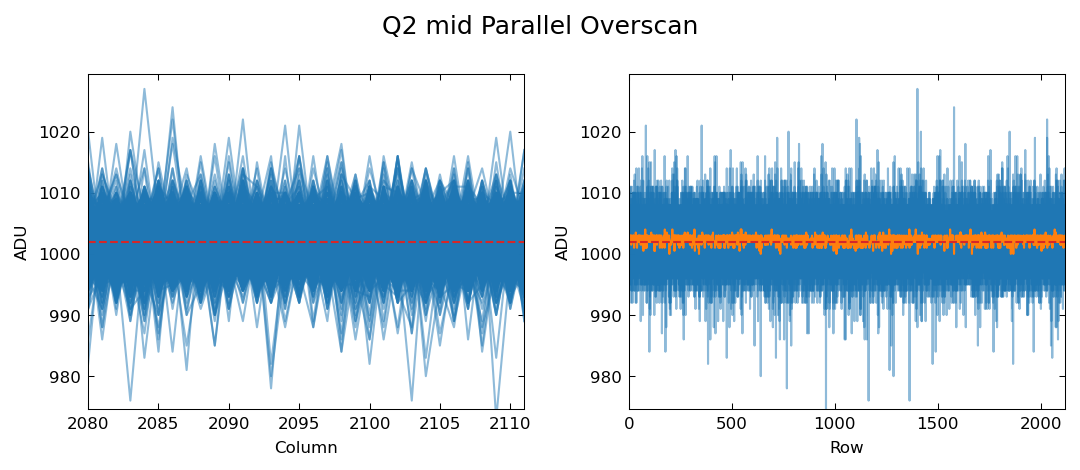

In [43]:
# Q2 mid parallel overscan
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Q2 mid Parallel Overscan')
xarr = np.arange(overscan_regions['q2_coordinates'][1][1]-overscan_range, overscan_regions['q2_coordinates'][1][1], 1)
for i in range(overscan_regions['q2_mid_parallel'].shape[0]):
    axes[0].plot(xarr, overscan_regions['q2_mid_parallel'][i,:], alpha=0.5, c='C0')
axes[0].plot(np.median(overscan_regions['q2_mid_parallel'], axis=0), color='C1')
# axes[0].axhline(np.median(overscan_regions['q2_mid_parallel']), color='C2', ls='--')
axes[0].axhline(q2_median, color='C3', ls='--')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_xlim(overscan_regions['q2_coordinates'][1][1]-overscan_range, overscan_regions['q2_coordinates'][1][1]-1)
axes[0].set_ylim(q2_median-5*q2_stdev, q2_median+5*q2_stdev)

xarr = np.arange(overscan_regions['q2_coordinates'][0][0], overscan_regions['q2_coordinates'][0][1], 1)
for i in range(overscan_regions['q2_mid_parallel'].shape[1]):
    axes[1].plot(xarr, overscan_regions['q2_mid_parallel'][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(overscan_regions['q2_mid_parallel'], axis=1), color='C1')
# axes[1].axhline(xarr, np.median(overscan_regions['q2_mid_parallel']), color='C2', ls='--')
axes[1].axhline(q2_median, color='C3', ls='--')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_xlim(overscan_regions['q2_coordinates'][0][0], overscan_regions['q2_coordinates'][0][1]-1)
axes[1].set_ylim(q2_median-5*q2_stdev, q2_median+5*q2_stdev)

plt.tight_layout()

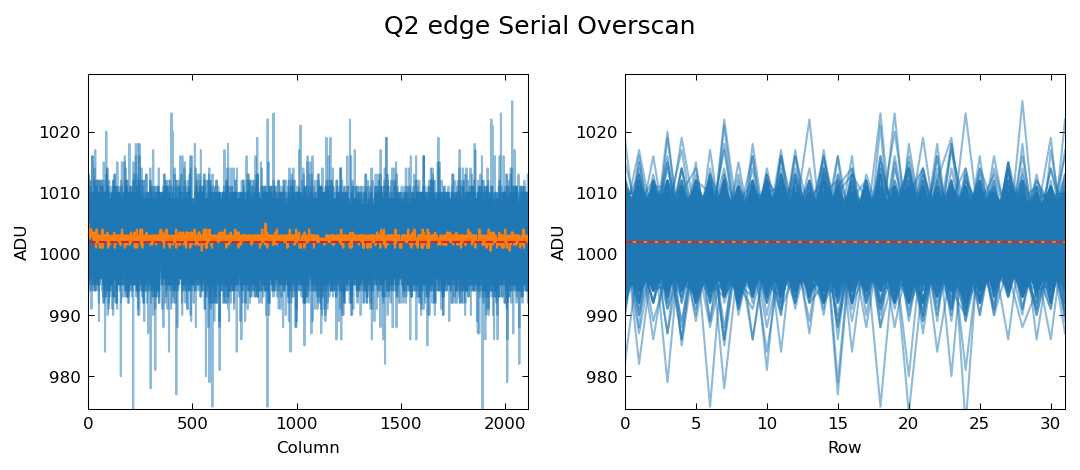

In [44]:
# Q2 edge serial overscan
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Q2 edge Serial Overscan')
xarr = np.arange(overscan_regions['q2_coordinates'][1][0], overscan_regions['q2_coordinates'][1][1], 1)
for i in range(overscan_regions['q2_edge_serial'].shape[0]):
    axes[0].plot(xarr, overscan_regions['q2_edge_serial'][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(overscan_regions['q2_edge_serial'], axis=0), color='C1')
# axes[0].axhline(np.median(overscan_regions['q2_edge_serial']), color='C2', ls='--')
axes[0].axhline(q2_median, color='C3', ls='--')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_xlim(overscan_regions['q2_coordinates'][1][0], overscan_regions['q2_coordinates'][1][1]-1)
axes[0].set_ylim(q2_median-5*q2_stdev, q2_median+5*q2_stdev)

xarr = np.arange(overscan_regions['q2_coordinates'][0][0], overscan_regions['q2_coordinates'][0][0]+overscan_range, 1)
for i in range(overscan_regions['q2_edge_serial'].shape[1]):
    axes[1].plot(xarr, overscan_regions['q2_edge_serial'][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(overscan_regions['q2_edge_serial'], axis=1), color='C1')
axes[1].axhline(q2_median, color='C3', ls='--')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_xlim(overscan_regions['q2_coordinates'][0][0], overscan_regions['q2_coordinates'][0][0]+overscan_range-1)
axes[1].set_ylim(q2_median-5*q2_stdev, q2_median+5*q2_stdev)
plt.tight_layout()  

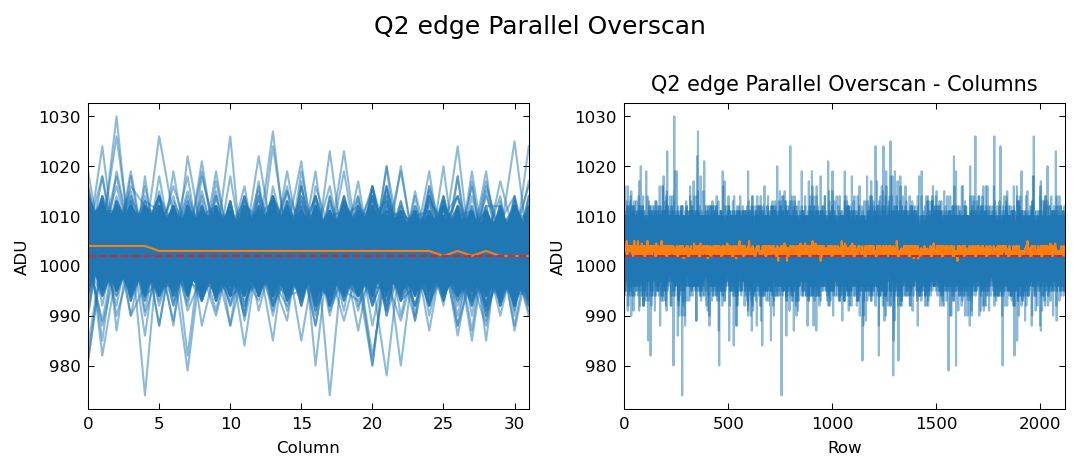

In [45]:
# Q2 edge parallel overscan
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Q2 edge Parallel Overscan')
xarr = np.arange(overscan_regions['q2_coordinates'][1][0], overscan_regions['q2_coordinates'][1][0]+overscan_range, 1)
for i in range(overscan_regions['q2_edge_parallel'].shape[0]):
    axes[0].plot(xarr, overscan_regions['q2_edge_parallel'][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(overscan_regions['q2_edge_parallel'], axis=0), color='C1')
axes[0].axhline(q2_median, color='C3', ls='--')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_xlim(overscan_regions['q2_coordinates'][1][0], overscan_regions['q2_coordinates'][1][0]+overscan_range-1)

xarr = np.arange(overscan_regions['q2_coordinates'][0][0], overscan_regions['q2_coordinates'][0][1], 1)
for i in range(overscan_regions['q2_edge_parallel'].shape[1]):
    axes[1].plot(xarr, overscan_regions['q2_edge_parallel'][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(overscan_regions['q2_edge_parallel'], axis=1), color='C1')
axes[1].axhline(q2_median, color='C3', ls='--')
axes[1].set_title('Q2 edge Parallel Overscan - Columns')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_xlim(overscan_regions['q2_coordinates'][0][0], overscan_regions['q2_coordinates'][0][1]-1)
plt.tight_layout()

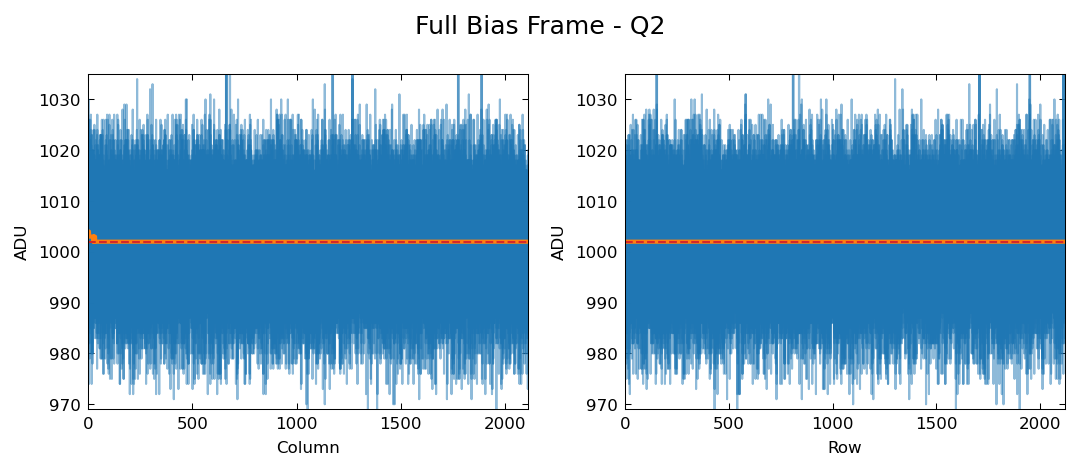

In [46]:
# full Q2 bias frame
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Full Bias Frame - Q2')
xarr = np.arange(overscan_regions['q2_coordinates'][1][0], overscan_regions['q2_coordinates'][1][1], 1)
for i in range(frame[:ydiv, :xdiv].shape[0]):
    axes[0].plot(xarr, frame[:ydiv, :xdiv][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(frame[:ydiv, :xdiv], axis=0), c='C1', linewidth=2)
axes[0].axhline(q2_median, color='C3', ls='--')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_ylim(np.percentile(frame[:ydiv, :xdiv], 1)-25, np.percentile(frame[:ydiv, :xdiv], 99)+25)
axes[0].set_xlim(overscan_regions['q2_coordinates'][1][0], overscan_regions['q2_coordinates'][1][1]-1)

xarr = np.arange(overscan_regions['q2_coordinates'][0][0], overscan_regions['q2_coordinates'][0][1], 1)
for i in range(frame[:ydiv, :xdiv].shape[1]):
    axes[1].plot(xarr, frame[:ydiv, :xdiv][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(frame[:ydiv, :xdiv], axis=1), c='C1', linewidth=2)
axes[1].axhline(q2_median, color='C3', ls='--')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_ylim(np.percentile(frame[:ydiv, :xdiv], 1)-25, np.percentile(frame[:ydiv, :xdiv], 99)+25)
axes[1].set_xlim(overscan_regions['q2_coordinates'][0][0], overscan_regions['q2_coordinates'][0][1]-1)

plt.tight_layout()

In [47]:
q2_median, np.median(frame[overscan_range:ydiv-overscan_range,overscan_range:xdiv-overscan_range])

(np.float64(1002.0), np.float64(1002.0))

### Q3

In [48]:
q3_overscans = np.concatenate(
    [overscan_regions['q3_mid_serial'][:,:].flatten(),
    overscan_regions['q3_mid_parallel'][overscan_range:-overscan_range,:].flatten(),
    overscan_regions['q3_edge_serial'][:,:].flatten(),
    overscan_regions['q3_edge_parallel'][overscan_range:-overscan_range,:].flatten()]
)
q3_median = np.median(q3_overscans)
q3_std = np.std(q3_overscans)
q3_median, q3_std

(np.float64(1005.0), np.float64(3.332034086120782))

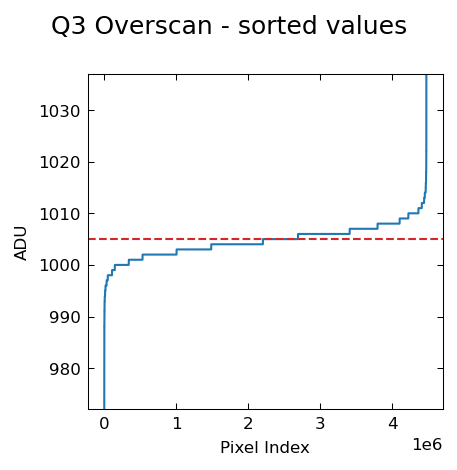

In [49]:
plt.close('all')
fig, axes = plt.subplots(1, 1, figsize=(3.15, 3.15), sharey=True)
fig.suptitle('Q3 Overscan - sorted values')

axes.plot(np.sort(frame[:ydiv, xdiv:].flatten()))
axes.axhline(q3_median, color='C3', ls='--')
# axes.set_yscale('log')
axes.set_xlabel('Pixel Index')
axes.set_ylabel('ADU')
axes.set_ylim(np.percentile(frame[:ydiv, xdiv:], 1)-25, np.percentile(frame[:ydiv, xdiv:], 99)+25)
plt.tight_layout()

In [50]:
overscan_regions['q3_coordinates']

[(0, 2120), (2112, 4224)]

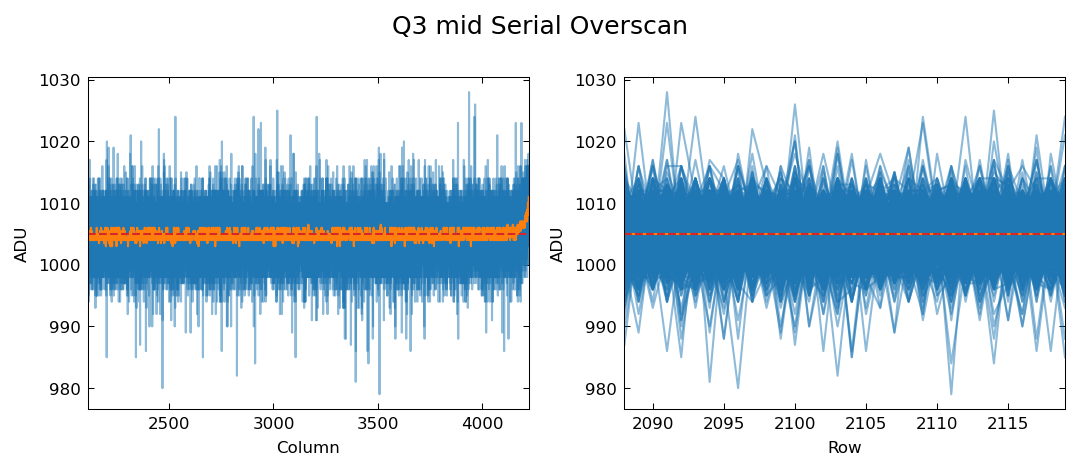

In [51]:
# Q3 mid serial overscan
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Q3 mid Serial Overscan')
xarr = np.arange(overscan_regions['q3_coordinates'][1][0], overscan_regions['q3_coordinates'][1][1], 1)
for i in range(overscan_regions['q3_mid_serial'].shape[0]):
    axes[0].plot(xarr, overscan_regions['q3_mid_serial'][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(overscan_regions['q3_mid_serial'], axis=0), color='C1')
# axes[0].axhline(np.median(overscan_regions['q3_mid_serial']), color='C2', ls='--')
axes[0].axhline(q3_median, color='C3', ls='--')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_xlim(overscan_regions['q3_coordinates'][1][0], overscan_regions['q3_coordinates'][1][1]-1)

xarr = np.arange(overscan_regions['q3_coordinates'][0][1]-overscan_range, overscan_regions['q3_coordinates'][0][1], 1)
for i in range(overscan_regions['q3_mid_serial'].shape[1]):
    axes[1].plot(xarr, overscan_regions['q3_mid_serial'][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(overscan_regions['q3_mid_serial'], axis=1), color='C1')
axes[1].axhline(q3_median, color='C3', ls='--')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_xlim(overscan_regions['q3_coordinates'][0][1]-overscan_range, overscan_regions['q3_coordinates'][0][1]-1)

plt.tight_layout()

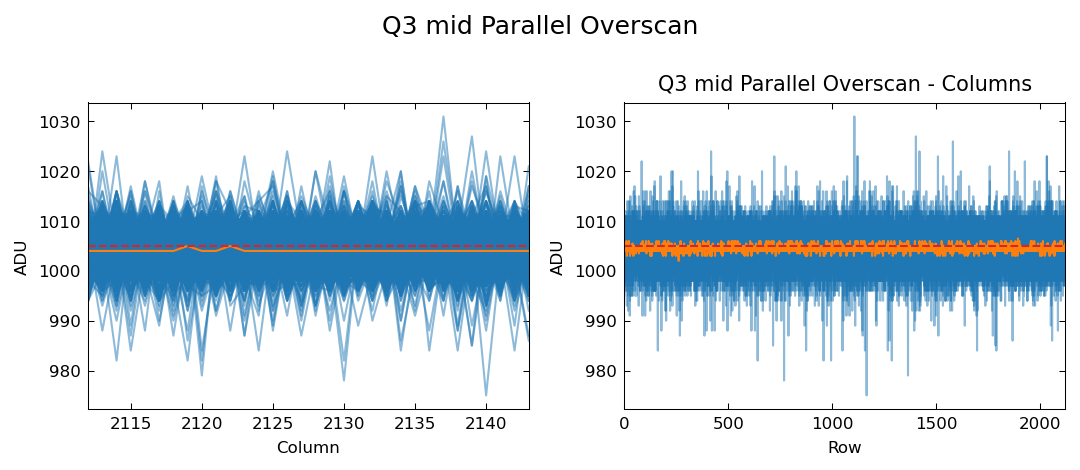

In [52]:
# Q3 mid parallel overscan
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Q3 mid Parallel Overscan')
xarr = np.arange(overscan_regions['q3_coordinates'][1][0], overscan_regions['q3_coordinates'][1][0]+overscan_range, 1)
for i in range(overscan_regions['q3_mid_parallel'].shape[0]):
    axes[0].plot(xarr, overscan_regions['q3_mid_parallel'][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(overscan_regions['q3_mid_parallel'], axis=0), color='C1')
axes[0].axhline(q3_median, color='C3', ls='--')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_xlim(overscan_regions['q3_coordinates'][1][0], overscan_regions['q3_coordinates'][1][0]+overscan_range-1)

xarr = np.arange(overscan_regions['q3_coordinates'][0][0], overscan_regions['q3_coordinates'][0][1], 1)
for i in range(overscan_regions['q3_mid_parallel'].shape[1]):
    axes[1].plot(xarr, overscan_regions['q3_mid_parallel'][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(overscan_regions['q3_mid_parallel'], axis=1), color='C1')
axes[1].axhline(q3_median, color='C3', ls='--')
axes[1].set_title('Q3 mid Parallel Overscan - Columns')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_xlim(overscan_regions['q3_coordinates'][0][0], overscan_regions['q3_coordinates'][0][1]-1)
plt.tight_layout()

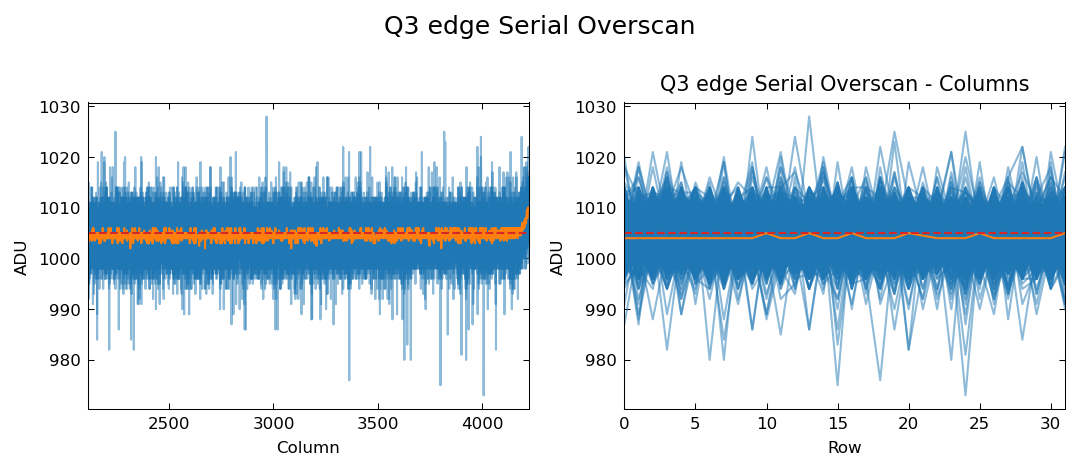

In [53]:
# Q3 edge serial overscan
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Q3 edge Serial Overscan')
xarr = np.arange(overscan_regions['q3_coordinates'][1][0], overscan_regions['q3_coordinates'][1][1], 1)
for i in range(overscan_regions['q3_edge_serial'].shape[0]):
    axes[0].plot(xarr, overscan_regions['q3_edge_serial'][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(overscan_regions['q3_edge_serial'], axis=0), color='C1')
# axes[0].axhline(np.median(overscan_regions['q3_edge_serial']), color='C2', ls='--')
axes[0].axhline(q3_median, color='C3', ls='--')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_xlim(overscan_regions['q3_coordinates'][1][0], overscan_regions['q3_coordinates'][1][1]-1)

xarr = np.arange(overscan_regions['q3_coordinates'][0][0], overscan_regions['q3_coordinates'][0][0]+overscan_range, 1)
for i in range(overscan_regions['q3_edge_serial'].shape[1]):
    axes[1].plot(xarr, overscan_regions['q3_edge_serial'][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(overscan_regions['q3_edge_serial'], axis=1), color='C1')
axes[1].axhline(q3_median, color='C3', ls='--')
axes[1].set_title('Q3 edge Serial Overscan - Columns')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_xlim(overscan_regions['q3_coordinates'][0][0], overscan_regions['q3_coordinates'][0][0]+overscan_range-1)

plt.tight_layout()

In [54]:
# plt.close('all')
# fig, axes = plt.subplots(1, 1, figsize=(3.15, 3.15))
# fig.suptitle('Q3 edge Serial Overscan - sorted values')
# plt.plot(np.sort(overscan_regions['q3_edge_serial'].flatten()))
# plt.axhline(q3_median, color='C3', ls='--')
# axes.set_xlabel('Pixel Index')
# axes.set_ylabel('ADU')
# plt.tight_layout()

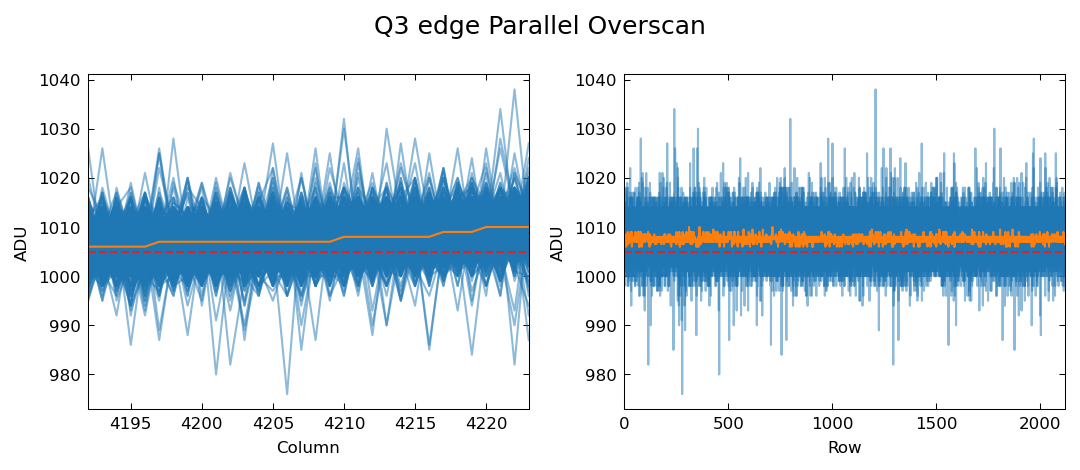

In [55]:
# Q3 edge parallel overscan
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Q3 edge Parallel Overscan')
xarr = np.arange(overscan_regions['q3_coordinates'][1][1]-overscan_range, overscan_regions['q3_coordinates'][1][1], 1)
for i in range(overscan_regions['q3_edge_parallel'].shape[0]):
    axes[0].plot(xarr, overscan_regions['q3_edge_parallel'][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(overscan_regions['q3_edge_parallel'], axis=0), color='C1')
axes[0].axhline(q3_median, color='C3', ls='--')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_xlim(overscan_regions['q3_coordinates'][1][1]-overscan_range, overscan_regions['q3_coordinates'][1][1]-1)


xarr = np.arange(overscan_regions['q3_coordinates'][0][0], overscan_regions['q3_coordinates'][0][1], 1)
for i in range(overscan_regions['q3_edge_parallel'].shape[1]):
    axes[1].plot(xarr, overscan_regions['q3_edge_parallel'][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(overscan_regions['q3_edge_parallel'], axis=1), color='C1')
axes[1].axhline(q3_median, color='C3', ls='--')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_xlim(overscan_regions['q3_coordinates'][0][0], overscan_regions['q3_coordinates'][0][1]-1)
plt.tight_layout()

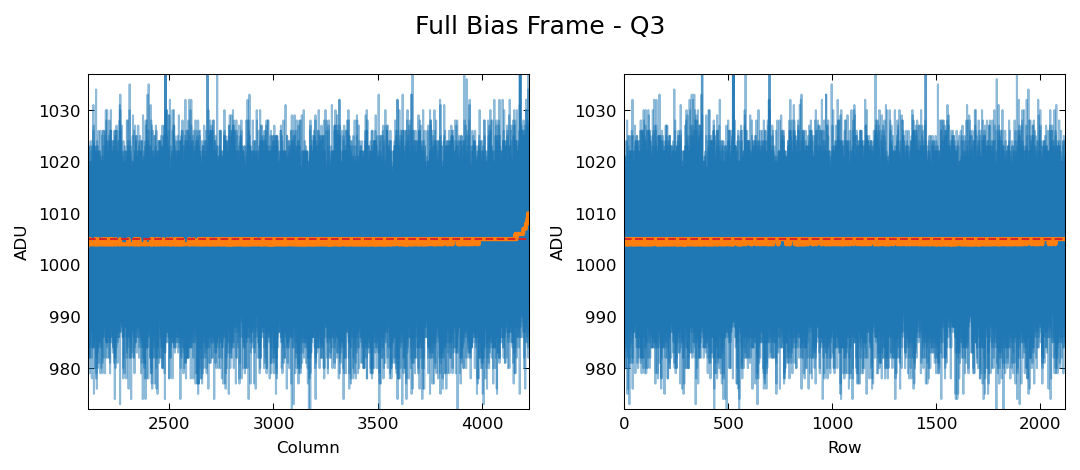

In [56]:
# full Q3 bias frame
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Full Bias Frame - Q3')
xarr = np.arange(overscan_regions['q3_coordinates'][1][0], overscan_regions['q3_coordinates'][1][1], 1)
for i in range(frame[:ydiv, xdiv:].shape[0]):
    axes[0].plot(xarr, frame[:ydiv, xdiv:][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(frame[:ydiv, xdiv:], axis=0), c='C1', linewidth=2)
axes[0].axhline(q3_median, color='C3', ls='--')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_ylim(np.percentile(frame[:ydiv, xdiv:], 1)-25, np.percentile(frame[:ydiv, xdiv:], 99)+25)
axes[0].set_xlim(overscan_regions['q3_coordinates'][1][0], overscan_regions['q3_coordinates'][1][1]-1)

xarr = np.arange(overscan_regions['q3_coordinates'][0][0], overscan_regions['q3_coordinates'][0][1], 1)
for i in range(frame[:ydiv, xdiv:].shape[1]):
    axes[1].plot(xarr, frame[:ydiv, xdiv:][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(frame[:ydiv, xdiv:], axis=1), c='C1', linewidth=2)
axes[1].axhline(q3_median, color='C3', ls='--')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_ylim(np.percentile(frame[:ydiv, xdiv:], 1)-25, np.percentile(frame[:ydiv, xdiv:], 99)+25)
axes[1].set_xlim(overscan_regions['q3_coordinates'][0][0], overscan_regions['q3_coordinates'][0][1]-1)
plt.tight_layout()

In [57]:
q3_median, np.median(frame[overscan_range:ydiv-overscan_range,xdiv+overscan_range:xlen-overscan_range])

(np.float64(1005.0), np.float64(1005.0))

### Q4

In [58]:
q4_overscans = np.concatenate(
    [overscan_regions['q4_mid_serial'][:,:].flatten(),
    overscan_regions['q4_mid_parallel'][overscan_range:-overscan_range,:].flatten(),
    overscan_regions['q4_edge_serial'][:,:].flatten(),
    overscan_regions['q4_edge_parallel'][overscan_range:-overscan_range,:].flatten()]
)
q4_median = np.median(q4_overscans)
q4_std = np.std(q4_overscans)
q4_median, q4_std

(np.float64(991.0), np.float64(2.970741366684574))

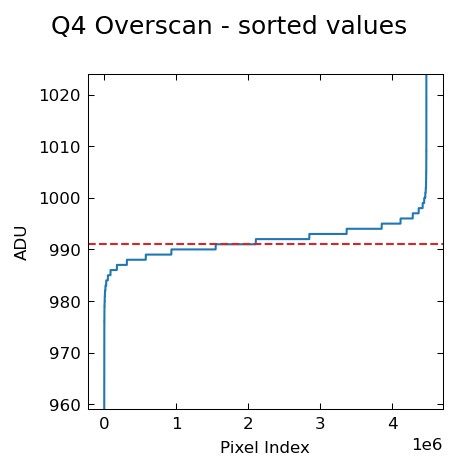

In [59]:
plt.close('all')
fig, axes = plt.subplots(1, 1, figsize=(3.15, 3.15), sharey=True)
fig.suptitle('Q4 Overscan - sorted values')

axes.plot(np.sort(frame[ydiv:, xdiv:].flatten()))
axes.axhline(q4_median, color='C3', ls='--')
# axes.set_yscale('log')
axes.set_xlabel('Pixel Index')
axes.set_ylabel('ADU')
axes.set_ylim(np.percentile(frame[ydiv:, xdiv:], 1)-25, np.percentile(frame[ydiv:, xdiv:], 99)+25)
plt.tight_layout()

In [60]:
overscan_regions['q4_coordinates']

[(2120, 4240), (2112, 4224)]

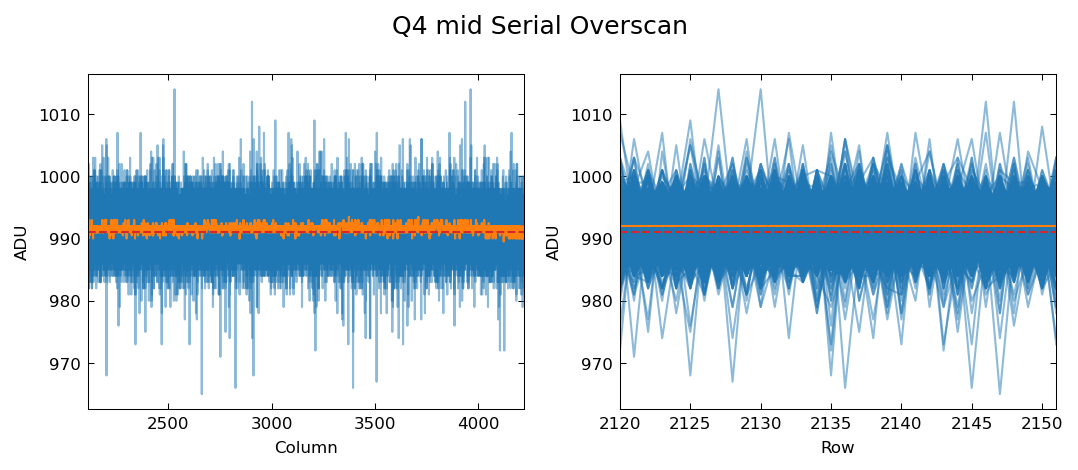

In [61]:
# Q4 mid serial overscan
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Q4 mid Serial Overscan')
xarr = np.arange(overscan_regions['q4_coordinates'][1][0], overscan_regions['q4_coordinates'][1][1], 1)
for i in range(overscan_regions['q4_mid_serial'].shape[0]):
    axes[0].plot(xarr, overscan_regions['q4_mid_serial'][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(overscan_regions['q4_mid_serial'], axis=0), color='C1')
# axes[0].axhline(np.median(overscan_regions['q4_mid_serial']), color='C2', ls='--')
axes[0].axhline(q4_median, color='C3', ls='--')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_xlim(overscan_regions['q4_coordinates'][1][0], overscan_regions['q4_coordinates'][1][1]-1)

xarr = np.arange(overscan_regions['q4_coordinates'][0][0], overscan_regions['q4_coordinates'][0][0]+overscan_range, 1)
for i in range(overscan_regions['q4_mid_serial'].shape[1]):
    axes[1].plot(xarr, overscan_regions['q4_mid_serial'][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(overscan_regions['q4_mid_serial'], axis=1), color='C1')
axes[1].axhline(q4_median, color='C3', ls='--')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_xlim(overscan_regions['q4_coordinates'][0][0], overscan_regions['q4_coordinates'][0][0]+overscan_range-1)
plt.tight_layout()

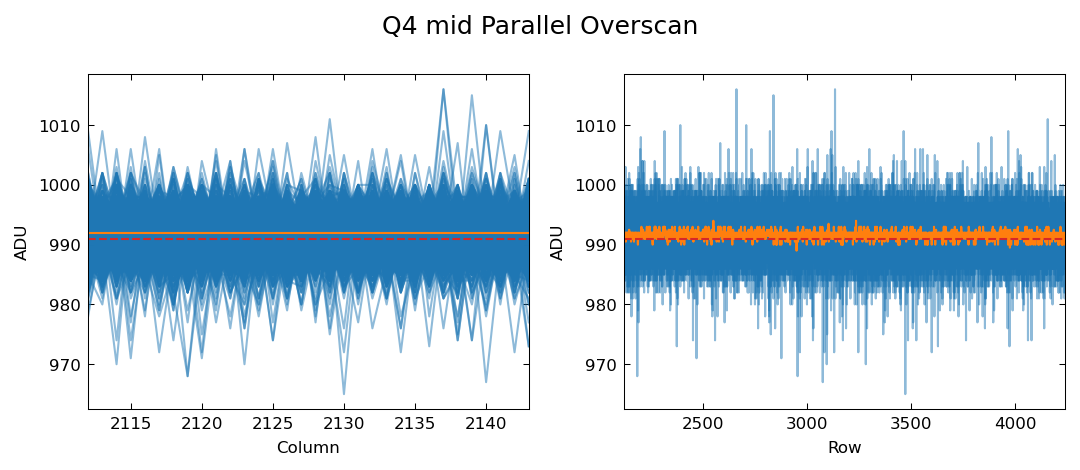

In [62]:
# Q4 mid parallel overscan
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Q4 mid Parallel Overscan')
xarr = np.arange(overscan_regions['q4_coordinates'][1][0], overscan_regions['q4_coordinates'][1][0]+overscan_range, 1)
for i in range(overscan_regions['q4_mid_parallel'].shape[0]):
    axes[0].plot(xarr, overscan_regions['q4_mid_parallel'][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(overscan_regions['q4_mid_parallel'], axis=0), color='C1')
axes[0].axhline(q4_median, color='C3', ls='--')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_xlim(overscan_regions['q4_coordinates'][1][0], overscan_regions['q4_coordinates'][1][0]+overscan_range-1)

xarr = np.arange(overscan_regions['q4_coordinates'][0][0], overscan_regions['q4_coordinates'][0][1], 1)
for i in range(overscan_regions['q4_mid_parallel'].shape[1]):
    axes[1].plot(xarr, overscan_regions['q4_mid_parallel'][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(overscan_regions['q4_mid_parallel'], axis=1), color='C1')
axes[1].axhline(q4_median, color='C3', ls='--')
axes[1].set_xlim(overscan_regions['q4_coordinates'][0][0], overscan_regions['q4_coordinates'][0][1]-1)
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_xlim(overscan_regions['q4_coordinates'][0][0], overscan_regions['q4_coordinates'][0][1]-1)
plt.tight_layout()

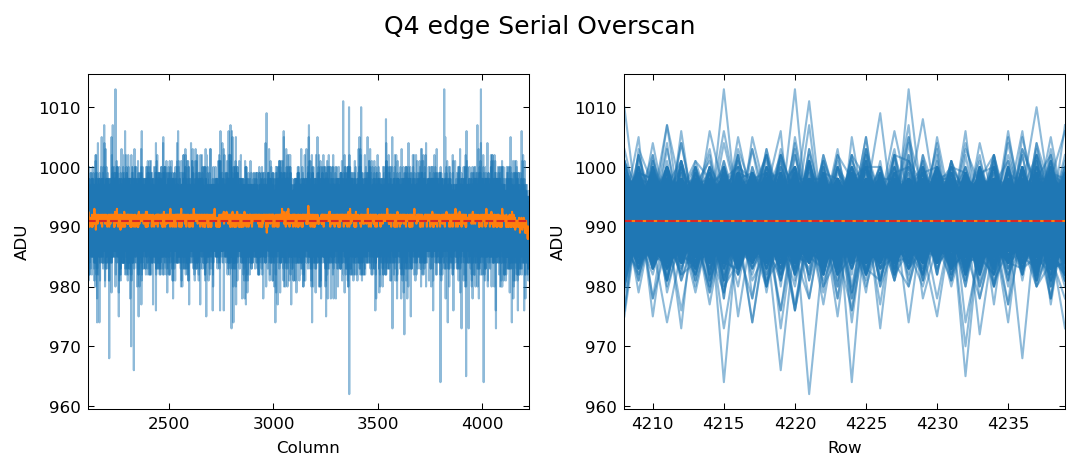

In [63]:
# Q4 edge serial overscan
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Q4 edge Serial Overscan')
xarr = np.arange(overscan_regions['q4_coordinates'][1][0], overscan_regions['q4_coordinates'][1][1], 1)
for i in range(overscan_regions['q4_edge_serial'].shape[0]):
    axes[0].plot(xarr, overscan_regions['q4_edge_serial'][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(overscan_regions['q4_edge_serial'], axis=0), color='C1')
axes[0].axhline(q4_median, color='C3', ls='--')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_xlim(overscan_regions['q4_coordinates'][1][0], overscan_regions['q4_coordinates'][1][1]-1)

xarr = np.arange(overscan_regions['q4_coordinates'][0][1]-overscan_range, overscan_regions['q4_coordinates'][0][1], 1)
for i in range(overscan_regions['q4_edge_serial'].shape[1]):
    axes[1].plot(xarr, overscan_regions['q4_edge_serial'][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(overscan_regions['q4_edge_serial'], axis=1), color='C1')
axes[1].axhline(q4_median, color='C3', ls='--')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_xlim(overscan_regions['q4_coordinates'][0][1]-overscan_range, overscan_regions['q4_coordinates'][0][1]-1)
plt.tight_layout()


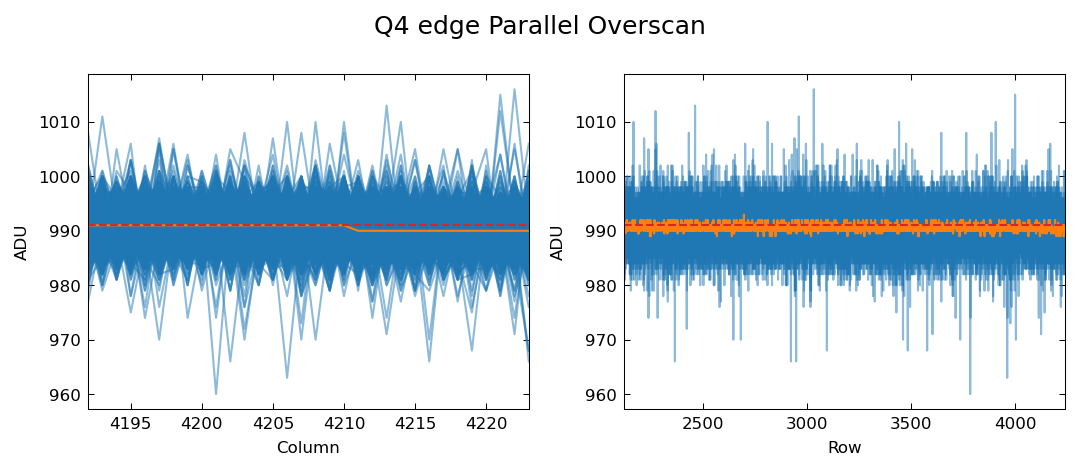

In [64]:
# Q4 edge parallel overscan
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Q4 edge Parallel Overscan')
xarr = np.arange(overscan_regions['q4_coordinates'][1][1]-overscan_range, overscan_regions['q4_coordinates'][1][1], 1)
for i in range(overscan_regions['q4_edge_parallel'].shape[0]):
    axes[0].plot(xarr, overscan_regions['q4_edge_parallel'][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(overscan_regions['q4_edge_parallel'], axis=0), color='C1')
axes[0].axhline(q4_median, color='C3', ls='--')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_xlim(overscan_regions['q4_coordinates'][1][1]-overscan_range, overscan_regions['q4_coordinates'][1][1]-1)

xarr = np.arange(overscan_regions['q4_coordinates'][0][0], overscan_regions['q4_coordinates'][0][1], 1)
for i in range(overscan_regions['q4_edge_parallel'].shape[1]):
    axes[1].plot(xarr, overscan_regions['q4_edge_parallel'][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(overscan_regions['q4_edge_parallel'], axis=1), color='C1')
axes[1].axhline(q4_median, color='C3', ls='--')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_xlim(overscan_regions['q4_coordinates'][0][0], overscan_regions['q4_coordinates'][0][1]-1)
plt.tight_layout() 

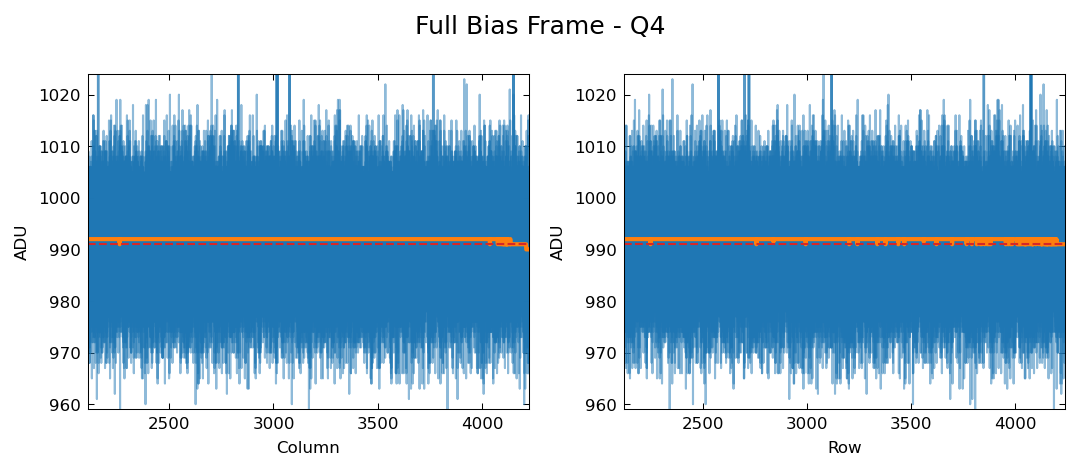

In [65]:
# full Q4 bias frame
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(7.3, 3.15))
fig.suptitle('Full Bias Frame - Q4')
xarr = np.arange(overscan_regions['q4_coordinates'][1][0], overscan_regions['q4_coordinates'][1][1], 1)
for i in range(frame[ydiv:, xdiv:].shape[0]):
    axes[0].plot(xarr, frame[ydiv:, xdiv:][i,:], alpha=0.5, c='C0')
axes[0].plot(xarr, np.median(frame[ydiv:, xdiv:], axis=0), c='C1', linewidth=2)
axes[0].axhline(q4_median, color='C3', ls='--')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('ADU')
axes[0].set_ylim(np.percentile(frame[ydiv:, xdiv:], 1)-25, np.percentile(frame[ydiv:, xdiv:], 99)+25)
axes[0].set_xlim(overscan_regions['q4_coordinates'][1][0], overscan_regions['q4_coordinates'][1][1]-1)

xarr = np.arange(overscan_regions['q4_coordinates'][0][0], overscan_regions['q4_coordinates'][0][1], 1)
for i in range(frame[ydiv:, xdiv:].shape[1]):
    axes[1].plot(xarr, frame[ydiv:, xdiv:][:,i], alpha=0.5, c='C0')
axes[1].plot(xarr, np.median(frame[ydiv:, xdiv:], axis=1), c='C1', linewidth=2)
axes[1].axhline(q4_median, color='C3', ls='--')
axes[1].set_xlabel('Row')
axes[1].set_ylabel('ADU')
axes[1].set_ylim(np.percentile(frame[ydiv:, xdiv:], 1)-25, np.percentile(frame[ydiv:, xdiv:], 99)+25)
axes[1].set_xlim(overscan_regions['q4_coordinates'][0][0], overscan_regions['q4_coordinates'][0][1]-1)
plt.tight_layout()

In [67]:
q4_median, np.median(frame[ydiv+overscan_range:ylen-overscan_range,xdiv+overscan_range:xlen-overscan_range])

(np.float64(991.0), np.float64(992.0))

### Conclusions:

The overscans that I called 'edge parallel overscans' (pre scans?) show some trend - falling towards detectors center in quadrants 1, 2 and 3, but raising for quadrant 4. With the exeption of Q4 taking median of the overscans give the same result as median of the quadrant itself (for Q4 diff is only 1 ADU).
